# 配套实践 01-02：认识机器人数据的张量形状

本练习对应基础篇第 01 章“机器人眼中的世界是什么”。我们用移动色块模拟相机画面，并配上机器人本体状态、动作和语言数据，理解 batch、time、channel 等维度各自表示什么。

每张图只回答一个问题。运行代码后，请先找出横轴、纵轴和颜色分别表示什么，再阅读图下方的解释。

<a href="https://qi-robotics.github.io/robot-world-model-tutorial/basics/01-robot-view-of-the-world/" target="_blank">在新标签页打开课程正文</a>

预计时间：10～15 分钟。不需要 GPU，也不需要下载外部数据。

## 使用方法

按照从上到下的顺序运行单元格。点击代码单元格左侧的运行按钮，或者按 Shift+Enter。移动色块只是为了让时间变化容易观察，不代表真实相机图像。

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

plt.rcParams["figure.dpi"] = 110
rng = np.random.default_rng(7)
print("环境准备完成")

环境准备完成


## 1. 一批数据包含哪些维度

先构造 2 条轨迹，每条轨迹包含 5 个时间步。每个时间步都有一张彩色图像、一组本体状态和一个动作。语言指令属于整条轨迹，因此只需要批次维度和语言长度维度。

In [2]:
B, T = 2, 5                  # 2 条轨迹，每条 5 个时间步
C, H, W = 3, 24, 24         # 彩色图像的通道、高度和宽度
P, A, L = 4, 3, 6           # 本体状态、动作、语言序列的长度

images = np.zeros((B, T, C, H, W), dtype=np.float32)
colors = np.array([[0.15, 0.45, 0.95], [0.95, 0.45, 0.15]])
for b in range(B):
    for t in range(T):
        left = 2 + 4 * t
        images[b, t, :, 8:16, left:left + 5] = colors[b, :, None, None]

proprio = np.zeros((B, T, P), dtype=np.float32)
for b in range(B):
    for t in range(T):
        proprio[b, t] = [0.2 * t, 0.1 * (t + b), -0.15 * t, 1.0 - 0.1 * t]

actions = rng.uniform(-0.2, 0.2, size=(B, T, A)).astype(np.float32)
language_tokens = np.array([[11, 24, 8, 31, 5, 2], [11, 17, 6, 28, 5, 2]])

print("图像：    ", images.shape, "= [B, T, C, H, W]")
print("本体状态：", proprio.shape, "= [B, T, P]")
print("动作：    ", actions.shape, "= [B, T, A]")
print("语言：    ", language_tokens.shape, "= [B, L]")

图像：     (2, 5, 3, 24, 24) = [B, T, C, H, W]
本体状态： (2, 5, 4) = [B, T, P]
动作：     (2, 5, 3) = [B, T, A]
语言：     (2, 6) = [B, L]


### 怎样理解这些形状

`B` 是 batch，表示一次取出的轨迹数量；这里 `B=2`，所以四类数据的第一个数字都是 2。`T` 是 time，表示每条轨迹包含多少个时间步；图像、本体状态和动作都随时间变化，所以它们都有 `T=5`。

图像后面的 `C, H, W` 分别是颜色通道、高度和宽度。一张图像的形状是 `[3, 24, 24]`。本体状态的 `P=4` 表示每个时刻用 4 个数字描述机器人自身；动作的 `A=3` 表示每个时刻发出 3 个控制量。语言形状中没有 `T`，因为本例假设一句指令描述整条轨迹，而不是每个时间步都有一句新指令。

## 2. 时间维度让单张图像变成运动过程

下面固定第 1 条轨迹，只沿时间维度依次取出 5 张图像。

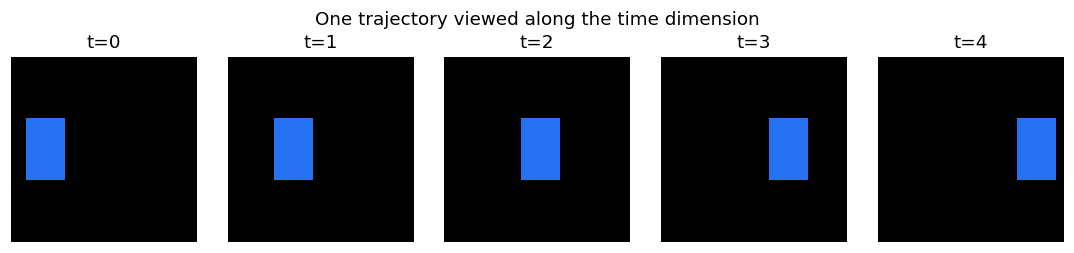

In [3]:
sample_index = 0
fig, axes = plt.subplots(1, T, figsize=(10, 2.3))
for t, ax in enumerate(axes):
    ax.imshow(np.moveaxis(images[sample_index, t], 0, -1))
    ax.set_title(f"t={t}")
    ax.axis("off")
fig.suptitle("One trajectory viewed along the time dimension")
plt.tight_layout()
plt.show()

### 怎样读这张图

五个小画面从左到右对应 `t=0` 到 `t=4`。蓝色方块不断向右移动，因此这些图像合在一起表达了一个运动过程。单看任意一张图，只能知道方块当时在哪里；按时间排列后，才能知道它向哪个方向移动。

代码中的 `images[sample_index, t]` 先固定第 1 条轨迹，再选择时间步 `t`。此时 batch 维和 time 维都已被选定，得到的是形状为 `[C, H, W]` 的单张图像。`np.moveaxis` 只是把颜色通道移到绘图库习惯的位置，数据表达的内容没有改变。

## 3. 本体状态也是按时间排列的

相机记录外部画面，本体状态记录机器人自身。下面仍然固定第 1 条轨迹，把形状为 `[T, P]` 的本体状态画成一张颜色图。

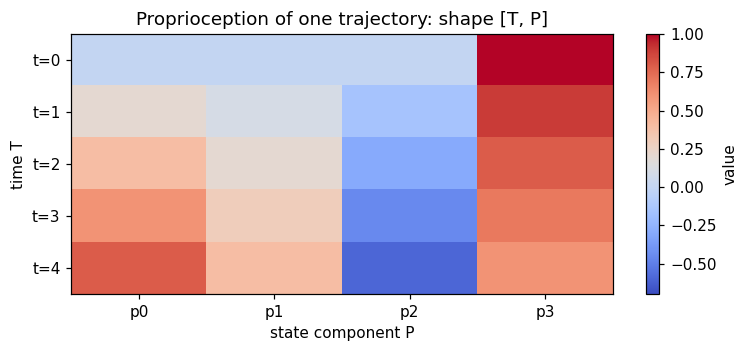

In [4]:
one_proprio_trajectory = proprio[0]

fig, ax = plt.subplots(figsize=(7, 3.3))
image = ax.imshow(one_proprio_trajectory, aspect="auto", cmap="coolwarm", vmin=-0.7, vmax=1.0)
ax.set_title("Proprioception of one trajectory: shape [T, P]")
ax.set_xlabel("state component P")
ax.set_ylabel("time T")
ax.set_xticks(np.arange(P), [f"p{i}" for i in range(P)])
ax.set_yticks(np.arange(T), [f"t={t}" for t in range(T)])
fig.colorbar(image, ax=ax, label="value")
plt.tight_layout()
plt.show()

### 怎样读这张图

每一行是一个时间步，因此共有 5 行；每一列是一个本体状态分量，因此共有 4 列。右侧色条说明颜色与数值的关系：偏蓝表示较小或为负的值，偏红表示较大的正值。这里不要求记住每个颜色对应的精确数字，而要先建立“行是时间、列是状态分量”的认识。

第一列 `p0` 从上到下逐渐增大，说明这个状态量随时间持续增加；第三列 `p2` 逐渐变小并变成负值，说明它沿相反方向变化。同一个时间步的整行数据，与上一张图中同一 `t` 的相机画面属于同一时刻，不能随意交换顺序。

## 4. 不同长度的轨迹需要有效位置标记

同一批数据必须具有统一的外形。假设第 1 条轨迹有 5 个真实时间步，第 2 条只有 3 个，较短轨迹末尾的两个位置就需要补齐。

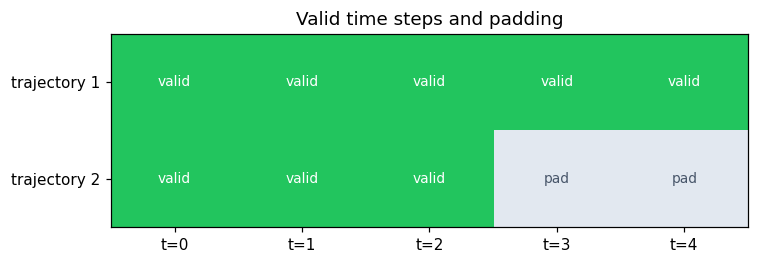

In [5]:
valid_lengths = np.array([5, 3])
time_mask = np.arange(T)[None, :] < valid_lengths[:, None]

fig, ax = plt.subplots(figsize=(7, 2.5))
mask_cmap = ListedColormap(["#e2e8f0", "#22c55e"])
ax.imshow(time_mask, aspect="auto", cmap=mask_cmap, vmin=0, vmax=1)
for b in range(B):
    for t in range(T):
        label = "valid" if time_mask[b, t] else "pad"
        color = "white" if time_mask[b, t] else "#475569"
        ax.text(t, b, label, ha="center", va="center", color=color, fontsize=9)
ax.set_xticks(np.arange(T), [f"t={t}" for t in range(T)])
ax.set_yticks(np.arange(B), ["trajectory 1", "trajectory 2"])
ax.set_title("Valid time steps and padding")
plt.tight_layout()
plt.show()

### 怎样读这张图

每一行代表一条轨迹，每一列代表一个时间步。绿色 `valid` 格子是真实记录，灰色 `pad` 格子只是为了把较短轨迹补到统一长度。第 1 条轨迹的 5 个位置都有效；第 2 条轨迹只有前 3 个位置有效，后 2 个位置不包含真实运动信息。

`time_mask` 的形状是 `[B, T]`，它与批次中的每条轨迹、每个时间步一一对应。模型计算平均值或训练误差时，要用这个标记排除灰色位置。补齐使数组能够整齐地组成一个 batch，但补齐值本身不能被当作机器人真的观测到的数据。

## 5. 为什么计算时必须忽略补齐位置

最后用第 2 条轨迹做一个简单比较。它的三个真实数值是 6、7、8，后面的两个 0 只是补齐。

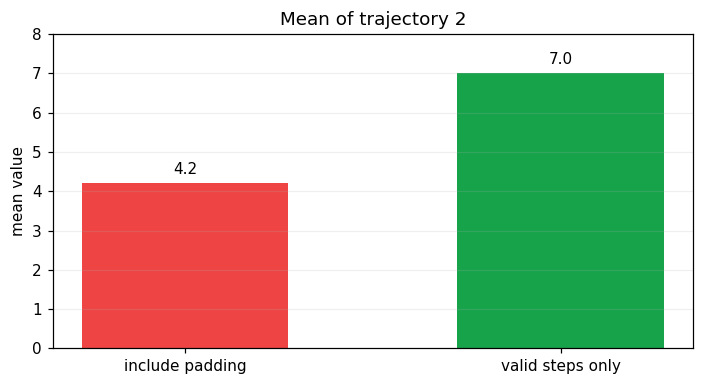

In [6]:
padded_values = np.array([6.0, 7.0, 8.0, 0.0, 0.0])
valid_mask = np.array([True, True, True, False, False])

mean_with_padding = padded_values.mean()
mean_valid_only = padded_values[valid_mask].mean()

labels = ["include padding", "valid steps only"]
means = [mean_with_padding, mean_valid_only]
fig, ax = plt.subplots(figsize=(6.5, 3.6))
bars = ax.bar(labels, means, color=["#ef4444", "#16a34a"], width=0.55)
ax.set_title("Mean of trajectory 2")
ax.set_ylabel("mean value")
ax.set_ylim(0, 8)
ax.bar_label(bars, labels=[f"{value:.1f}" for value in means], padding=4)
ax.grid(axis="y", alpha=0.2)
plt.tight_layout()
plt.show()

### 怎样读这张图

红色柱把五个位置全部参与平均，计算得到 `(6+7+8+0+0)/5 = 4.2`。绿色柱只使用三个真实时间步，计算得到 `(6+7+8)/3 = 7.0`。两根柱子的差异完全来自两个补齐用的 0。

如果训练时不使用有效位置标记，模型会误以为后两个 0 也是真实数据，从而得到偏低的平均值或错误的训练误差。因此，padding 解决的是“怎样把不同长度轨迹放进同一个张量”，mask 解决的是“怎样让补齐位置不参与学习”。这两个概念通常需要配合使用。

## 练习与小结

1. 将 `T` 从 5 改为 6，并相应调整 `valid_lengths`，观察哪些图发生变化。
2. 把第 2 条轨迹的有效长度从 3 改为 4，重新运行第 4、5 节，并给 `padded_values` 增加一个真实数值。
3. 修改本体状态生成代码中的一个变化规律，观察第 3 节颜色图中的对应列。

本练习建立了四个基本认识：batch 组织多条轨迹；time 保留先后顺序；不同数据有各自的内部维度；不同长度的轨迹需要同时使用 padding 和 mask。